# Empirische und exakte Verteilung einer Lückenlänge

Für $w$ weiße und $s$ schwarze Kugeln werden zufällige Farbanordnungen gleichverteilt simuliert. Für eine ausgewählte Lücke $L_i$ vergleicht das Notebook die empirische relative Häufigkeit $h_R(L_i=\ell)$ mit der exakten Wahrscheinlichkeit $\mathbb P(L_i=\ell)$.

Der feste NumPy-Generator `np.random.default_rng(SEED)` macht die Ergebnisse reproduzierbar. Legende, Wilson-Intervalle, Kennwerte und Titel können in der nächsten Zelle unabhängig ein- oder ausgeschaltet werden.


## 1. Einstellungen und Importe


In [20]:
"""Empirische und exakte Verteilung einer Lueckenlaenge.

Das Programm simuliert gleichverteilte Farbanordnungen mit ``w`` weissen
und ``s`` schwarzen Kugeln. Die empirische Verteilung einer ausgewaehlten
Luecke wird mit ihrer exakten Randverteilung verglichen.

Reproduzierbarkeit:
    NumPy Generator ``np.random.default_rng(SEED)`` mit festem Seed.

Ausgaben (relativ zum Speicherort dieses Programms):
    output/pdf/lueckenverteilung_empirisch_exakt.pdf
    output/figures/lueckenverteilung_empirisch_exakt.png
    output/data/lueckenverteilung_empirisch_exakt.csv
"""

from __future__ import annotations

import csv
from math import comb
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------------
# Einstellungen
# ---------------------------------------------------------------------------

W = 10                       # Anzahl weisser Kugeln
S = 15                       # Anzahl schwarzer Kugeln
ANZAHL_SIMULATIONEN = 10_000
LUECKE = 1                   # L_1, ..., L_{W+1}
SEED = 42

# Diese Bestandteile koennen unabhaengig ein- und ausgeschaltet werden.
ZEIGE_LEGENDE = True              # sonst: False 
ZEIGE_WILSON_INTERVALLE = True
ZEIGE_KENNWERTE = True
ZEIGE_TITEL = True

# Die beiden Strecken liegen symmetrisch links und rechts von ell.
VERSATZ = 0.11

PROGRAMMORDNER = Path.cwd()
PDF_DATEI = PROGRAMMORDNER / "output/pdf/lueckenverteilung_empirisch_exakt.pdf"
PNG_DATEI = PROGRAMMORDNER / "output/figures/lueckenverteilung_empirisch_exakt.png"
CSV_DATEI = PROGRAMMORDNER / "output/data/lueckenverteilung_empirisch_exakt.csv"




## 2. Simulation und theoretische Verteilung


In [21]:
# ---------------------------------------------------------------------------
# Simulation und Theorie
# ---------------------------------------------------------------------------

def bestimme_luecken(anordnung: np.ndarray) -> np.ndarray:
    """Bestimmt L_1, ..., L_{w+1} einer 0-1-Farbanordnung.

    1 steht fuer eine weisse, 0 fuer eine schwarze Kugel.
    """

    w = int(anordnung.sum())
    luecken = np.zeros(w + 1, dtype=int)
    aktuelle_luecke = 0

    for kugel in anordnung:
        if kugel == 1:
            aktuelle_luecke += 1
        else:
            luecken[aktuelle_luecke] += 1

    return luecken


def simuliere_luecken(w: int, s: int, r: int, seed: int) -> np.ndarray:
    """Erzeugt r unabhaengige, gleichverteilte Farbanordnungen."""

    if not isinstance(w, (int, np.integer)) or w < 1:
        raise ValueError("W muss eine positive ganze Zahl sein.")
    if not isinstance(s, (int, np.integer)) or s < 0:
        raise ValueError("S muss eine nichtnegative ganze Zahl sein.")
    if not isinstance(r, (int, np.integer)) or r < 1:
        raise ValueError("ANZAHL_SIMULATIONEN muss positiv und ganzzahlig sein.")

    # Der Generator wird genau einmal initialisiert und anschliessend
    # fuer alle Simulationen weiterverwendet.
    rng = np.random.default_rng(seed)
    grundanordnung = np.array([1] * w + [0] * s, dtype=np.int8)
    ergebnisse = np.empty((r, w + 1), dtype=int)

    for nr in range(r):
        ergebnisse[nr] = bestimme_luecken(rng.permutation(grundanordnung))

    return ergebnisse


def exakte_verteilung(w: int, s: int) -> np.ndarray:
    """Berechnet P(L_i=ell), ell=0,...,s, fuer eine beliebige Luecke."""

    n = w + s
    nenner = comb(n, w)
    return np.array(
        [comb(n - ell - 1, w - 1) / nenner for ell in range(s + 1)],
        dtype=float,
    )


def wilson_intervalle(
    treffer: np.ndarray,
    n: int,
    konfidenzniveau: float = 0.95,
) -> tuple[np.ndarray, np.ndarray]:
    """Punktweise Wilson-Intervalle fuer mehrere relative Haeufigkeiten."""

    p_dach = treffer / n
    z = NormalDist().inv_cdf(1 - (1 - konfidenzniveau) / 2)
    nenner = 1 + z**2 / n
    mitte = (p_dach + z**2 / (2 * n)) / nenner
    halbbreite = z / nenner * np.sqrt(
        p_dach * (1 - p_dach) / n + z**2 / (4 * n**2)
    )
    return mitte - halbbreite, mitte + halbbreite




## 3. Auswertung und CSV-Export


In [22]:
# ---------------------------------------------------------------------------
# Auswertung
# ---------------------------------------------------------------------------

if not 1 <= LUECKE <= W + 1:
    raise ValueError("LUECKE muss zwischen 1 und W+1 liegen.")

luecken = simuliere_luecken(W, S, ANZAHL_SIMULATIONEN, SEED)
beobachtungen = luecken[:, LUECKE - 1]
ell = np.arange(S + 1)

absolute_haeufigkeiten = np.bincount(beobachtungen, minlength=S + 1)
empirisch = absolute_haeufigkeiten / ANZAHL_SIMULATIONEN
exakt = exakte_verteilung(W, S)
wilson_unten, wilson_oben = wilson_intervalle(
    absolute_haeufigkeiten,
    ANZAHL_SIMULATIONEN,
)

empirischer_mittelwert = beobachtungen.mean()
empirische_varianz = beobachtungen.var(ddof=0)
empirische_standardabweichung = beobachtungen.std(ddof=0)

theoretischer_mittelwert = S / (W + 1)
theoretische_varianz = W * S * (W + S + 1) / ((W + 1) ** 2 * (W + 2))
theoretische_standardabweichung = np.sqrt(theoretische_varianz)


# ---------------------------------------------------------------------------
# Datenexport
# ---------------------------------------------------------------------------

for datei in (PDF_DATEI, PNG_DATEI, CSV_DATEI):
    datei.parent.mkdir(parents=True, exist_ok=True)

with CSV_DATEI.open("w", newline="", encoding="utf-8") as datei:
    writer = csv.writer(datei, delimiter=";")
    writer.writerow(
        [
            "ell",
            "absolute_Haeufigkeit",
            "relative_Haeufigkeit",
            "exakte_Wahrscheinlichkeit",
            "Wilson_95_unten",
            "Wilson_95_oben",
        ]
    )
    for zeile in zip(
        ell,
        absolute_haeufigkeiten,
        empirisch,
        exakt,
        wilson_unten,
        wilson_oben,
        strict=True,
    ):
        writer.writerow(zeile)




## 4. Abbildung

Empirische und exakte Werte werden als zwei getrennte Strecken symmetrisch links und rechts der ganzzahligen Lückenlänge $\ell$ dargestellt.


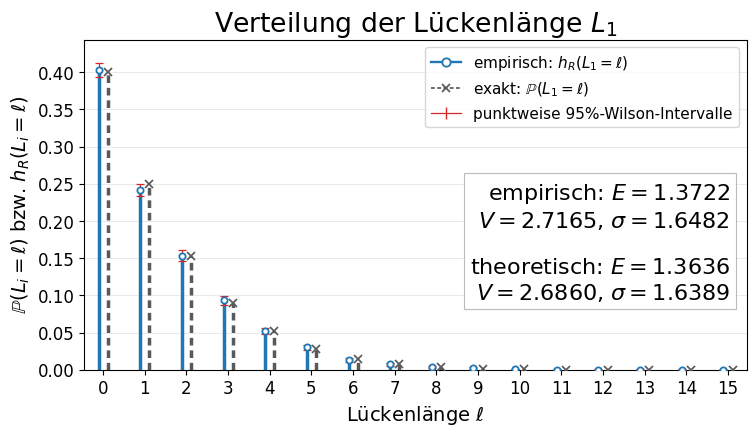

NumPy Generator: np.random.default_rng(42)
Empirisch:  E=1.3722, V=2.7165, sigma=1.6482
Theoretisch: E=1.3636, V=2.6860, sigma=1.6389
PDF: /Users/reimund/Documents/Arbeit/Projekte/Symmetrie_elementare_Stochastik/scr/python/output/pdf/lueckenverteilung_empirisch_exakt.pdf
PNG: /Users/reimund/Documents/Arbeit/Projekte/Symmetrie_elementare_Stochastik/scr/python/output/figures/lueckenverteilung_empirisch_exakt.png
CSV: /Users/reimund/Documents/Arbeit/Projekte/Symmetrie_elementare_Stochastik/scr/python/output/data/lueckenverteilung_empirisch_exakt.csv


In [23]:
# ---------------------------------------------------------------------------
# Abbildung
# ---------------------------------------------------------------------------

plt.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 14,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

farbe_empirisch = "tab:blue"   
farbe_exakt = "0.35"      
farbe_intervall = "tab:red"  #  "#7A7A7A"

x_empirisch = ell - VERSATZ
x_exakt = ell + VERSATZ

fig, ax = plt.subplots(figsize=(7.45, 4.25), constrained_layout=True)

# Zwei getrennte Strecken, symmetrisch um jedes ganzzahlige ell.
ax.vlines(
    x_empirisch,
    0,
    empirisch,
    color=farbe_empirisch,
    linewidth=2.5,
    zorder=2,
)
ax.plot(
    x_empirisch,
    empirisch,
    linestyle="none",
    marker="o",
    markersize=4.5,
    markerfacecolor="white",
    markeredgecolor=farbe_empirisch,
    markeredgewidth=1.3,
    zorder=4,
)

ax.vlines(
    x_exakt,
    0,
    exakt,
    color=farbe_exakt,
    linewidth=2.5,
    linestyles=(0, (2.2, 1.4)),
    zorder=2,
)
ax.plot(
    x_exakt,
    exakt,
    linestyle="none",
    marker="x",
    markersize=5.2,
    markeredgewidth=1.25,
    color=farbe_exakt,
    zorder=4,
)

if ZEIGE_WILSON_INTERVALLE:
    ax.errorbar(
        x_empirisch,
        empirisch,
        yerr=np.vstack((empirisch - wilson_unten, wilson_oben - empirisch)),
        fmt="none",
        ecolor=farbe_intervall,
        elinewidth=0.9,
        capsize=2.6,
        capthick=0.9,
        zorder=3,
    )

if ZEIGE_KENNWERTE:
    kennwerte = (
        rf"empirisch: $E={empirischer_mittelwert:.4f}$" + "\n"
        + rf"$V={empirische_varianz:.4f}$, "
        + rf"$\sigma={empirische_standardabweichung:.4f}$" + "\n\n"
        + rf"theoretisch: $E={theoretischer_mittelwert:.4f}$" + "\n"
        + rf"$V={theoretische_varianz:.4f}$, "
        + rf"$\sigma={theoretische_standardabweichung:.4f}$"
    )
    ax.text(
        0.975,
        0.57,
        kennwerte,
        ha="right",
        va="top",
        transform=ax.transAxes,
        bbox={
            "facecolor": "white",
            "edgecolor": "0.72",
            "linewidth": 0.8,
            "alpha": 0.95,
            "pad": 4.5,
        },
    )

if ZEIGE_LEGENDE:
    handles = [
        Line2D(
            [0],
            [0],
            color=farbe_empirisch,
            linewidth=1.7,
            marker="o",
            markerfacecolor="white",
            markeredgewidth=1.3,
            label=rf"empirisch: $h_R(L_{{{LUECKE}}}=\ell)$",
        ),
        Line2D(
            [0],
            [0],
            color=farbe_exakt,
            linewidth=1.25,
            linestyle=(0, (2.2, 1.4)),
            marker="x",
            markeredgewidth=1.25,
            label=rf"exakt: $\mathbb{{P}}(L_{{{LUECKE}}}=\ell)$",
        ),
    ]
    if ZEIGE_WILSON_INTERVALLE:
        handles.append(
            Line2D(
                [0],
                [0],
                color=farbe_intervall,
                linewidth=0.9,
                marker="|",
                markersize=8,
                label="punktweise 95%-Wilson-Intervalle",
            )
        )
    ax.legend(handles=handles, loc="upper right", frameon=True)

if ZEIGE_TITEL:
    ax.set_title(rf"Verteilung der Lückenlänge $L_{{{LUECKE}}}$")

ax.set_xlabel(r"Lückenlänge $\ell$")
ax.set_ylabel(r"$\mathbb{P}(L_i=\ell)$ bzw. $h_R(L_i=\ell)$")
ax.set_xticks(ell)
ax.set_xlim(-0.45, S + 0.45)
ax.set_ylim(0, max(exakt.max(), empirisch.max(), wilson_oben.max()) * 1.075)
ax.grid(axis="y", color="0.90", linewidth=0.6)
ax.set_axisbelow(True)

fig.savefig(PDF_DATEI, bbox_inches="tight")
fig.savefig(PNG_DATEI, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"NumPy Generator: np.random.default_rng({SEED})")
print(f"Empirisch:  E={empirischer_mittelwert:.4f}, "
      f"V={empirische_varianz:.4f}, sigma={empirische_standardabweichung:.4f}")
print(f"Theoretisch: E={theoretischer_mittelwert:.4f}, "
      f"V={theoretische_varianz:.4f}, sigma={theoretische_standardabweichung:.4f}")
print(f"PDF: {PDF_DATEI}")
print(f"PNG: {PNG_DATEI}")
print(f"CSV: {CSV_DATEI}")
